# Proyek Predictive Analytics : Wine Quality Dataset
- **Nama:** Atifa Fiorenza
- **Email:** atifafiorenza24@gmail.com
- **ID Dicoding:** atifafiorenza24

## Import Library

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import itertools
import joblib

from imblearn.over_sampling import SMOTE
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

## Download Dataset

In [2]:
from google.colab import files
files.upload()  # Upload file kaggle.json dari lokal

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"atifa1110","key":"2972f282815cfd20a65bc10625d79e46"}'}

In [3]:
# Membuat folder .kaggle untuk credentials
!mkdir -p ~/.kaggle

# Menyalin file kaggle.json ke folder .kaggle
!cp kaggle.json ~/.kaggle/kaggle.json

# Memberikan permission agar kaggle.json dapat digunakan
!chmod 600 ~/.kaggle/kaggle.json

# Mendownload dataset Rice Leaf Diseases dari Kaggle
!kaggle datasets download -d yasserh/wine-quality-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
License(s): CC0-1.0
  0% 0.00/21.5k [00:00<?, ?B/s]
100% 21.5k/21.5k [00:00<00:00, 72.9MB/s]


In [4]:
# Mengekstrak file dataset
!unzip wine-quality-dataset.zip -d wine

Archive:  wine-quality-dataset.zip
  inflating: wine/WineQT.csv         


Load Dataset

In [5]:
dataset = 'wine/WineQT.csv'

# Membaca CSV
df = pd.read_csv(dataset)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [6]:
df.shape

(1143, 13)

## Dataset Preprocessing

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


> Cek null

In [8]:
# Menampilkan jumlah missing value per kolom
missing_values = df.isnull().sum()

# Filter hanya kolom dengan missing value > 0
missing_values = missing_values[missing_values > 0]

print(missing_values)

Series([], dtype: int64)


> Cek duplicats

In [9]:
df[df.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id


In [10]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerik :", num_cols)

Numerik : Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')


## Distribusi tiap fitur


> Numerik

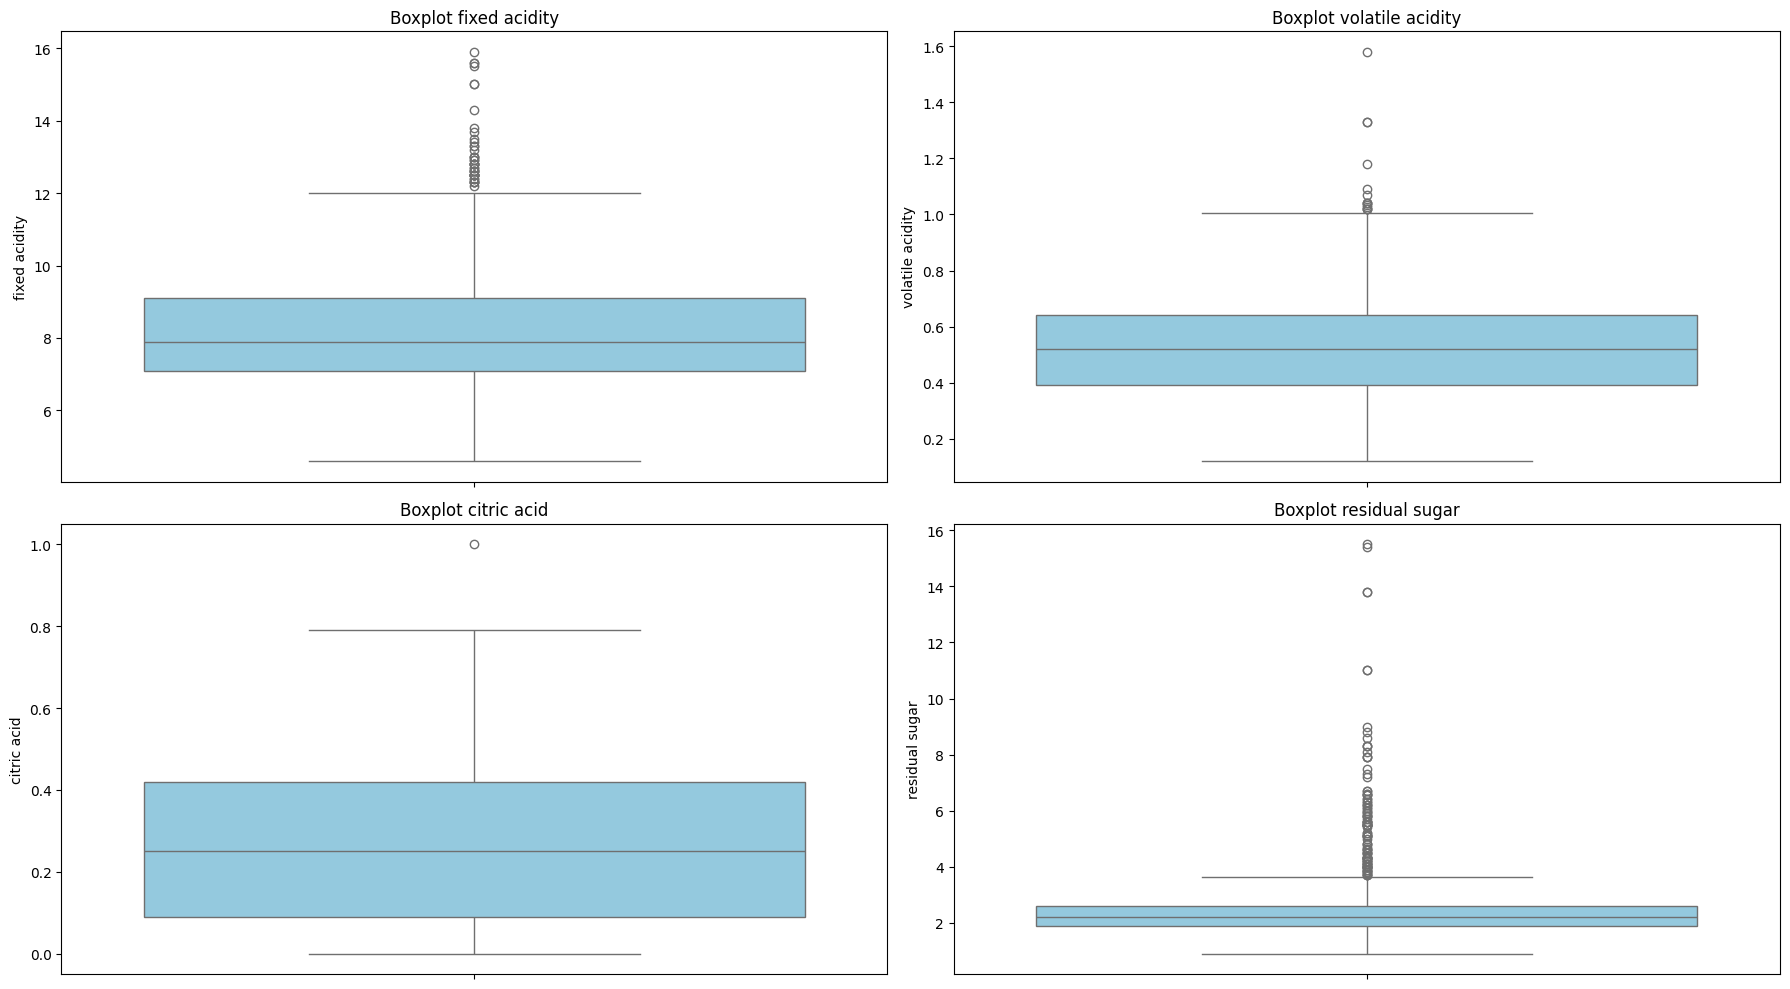

In [16]:
num_cols1= ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar']
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols1):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

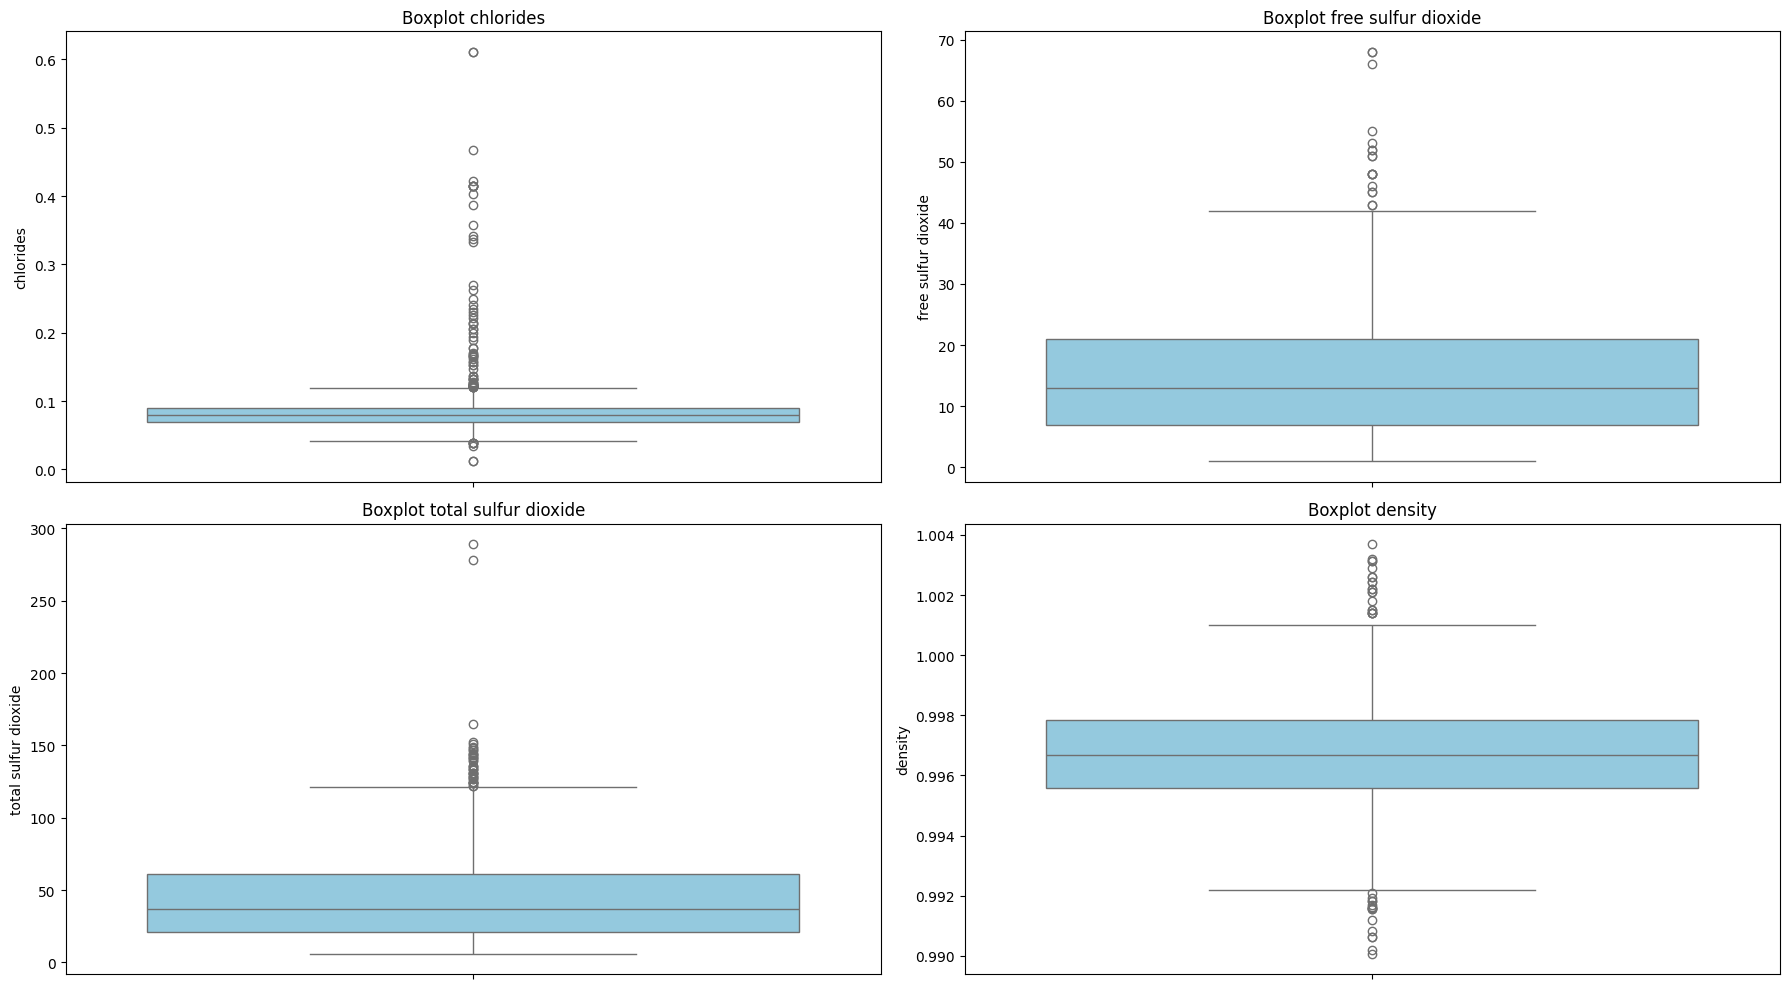

In [15]:
num_cols2= ['chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',]
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols2):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

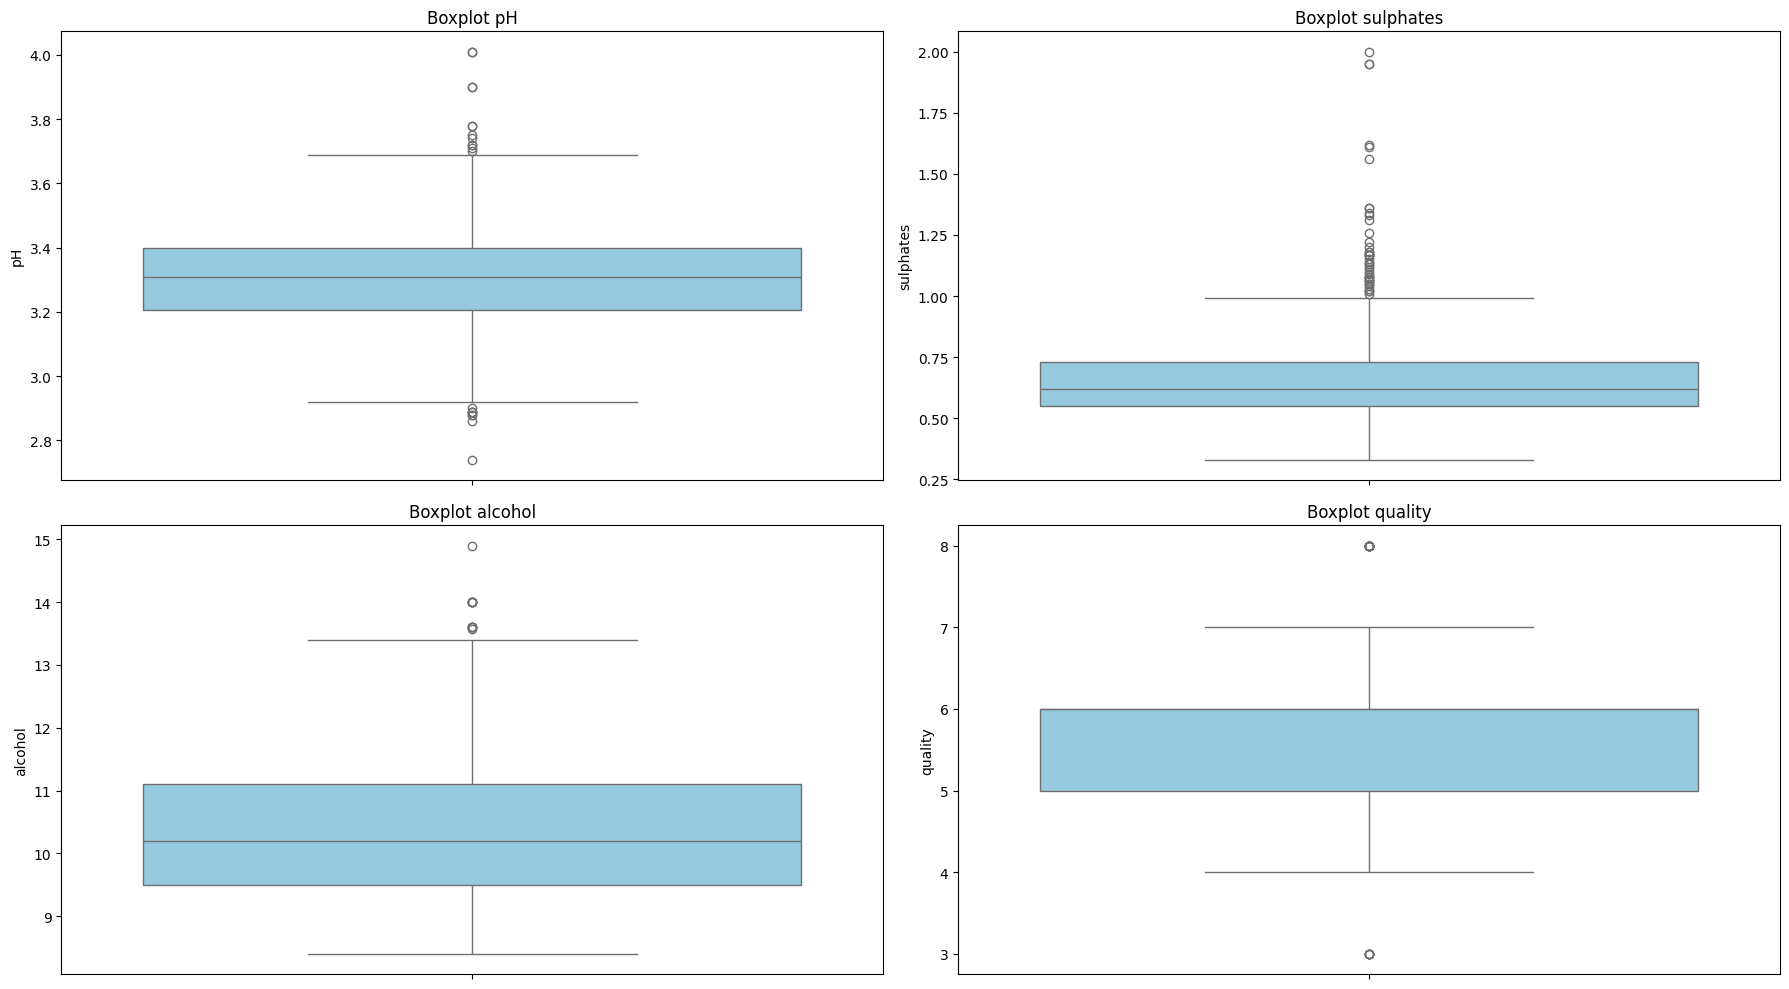

In [19]:
num_cols3= ['pH', 'sulphates', 'alcohol', 'quality']
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols3):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

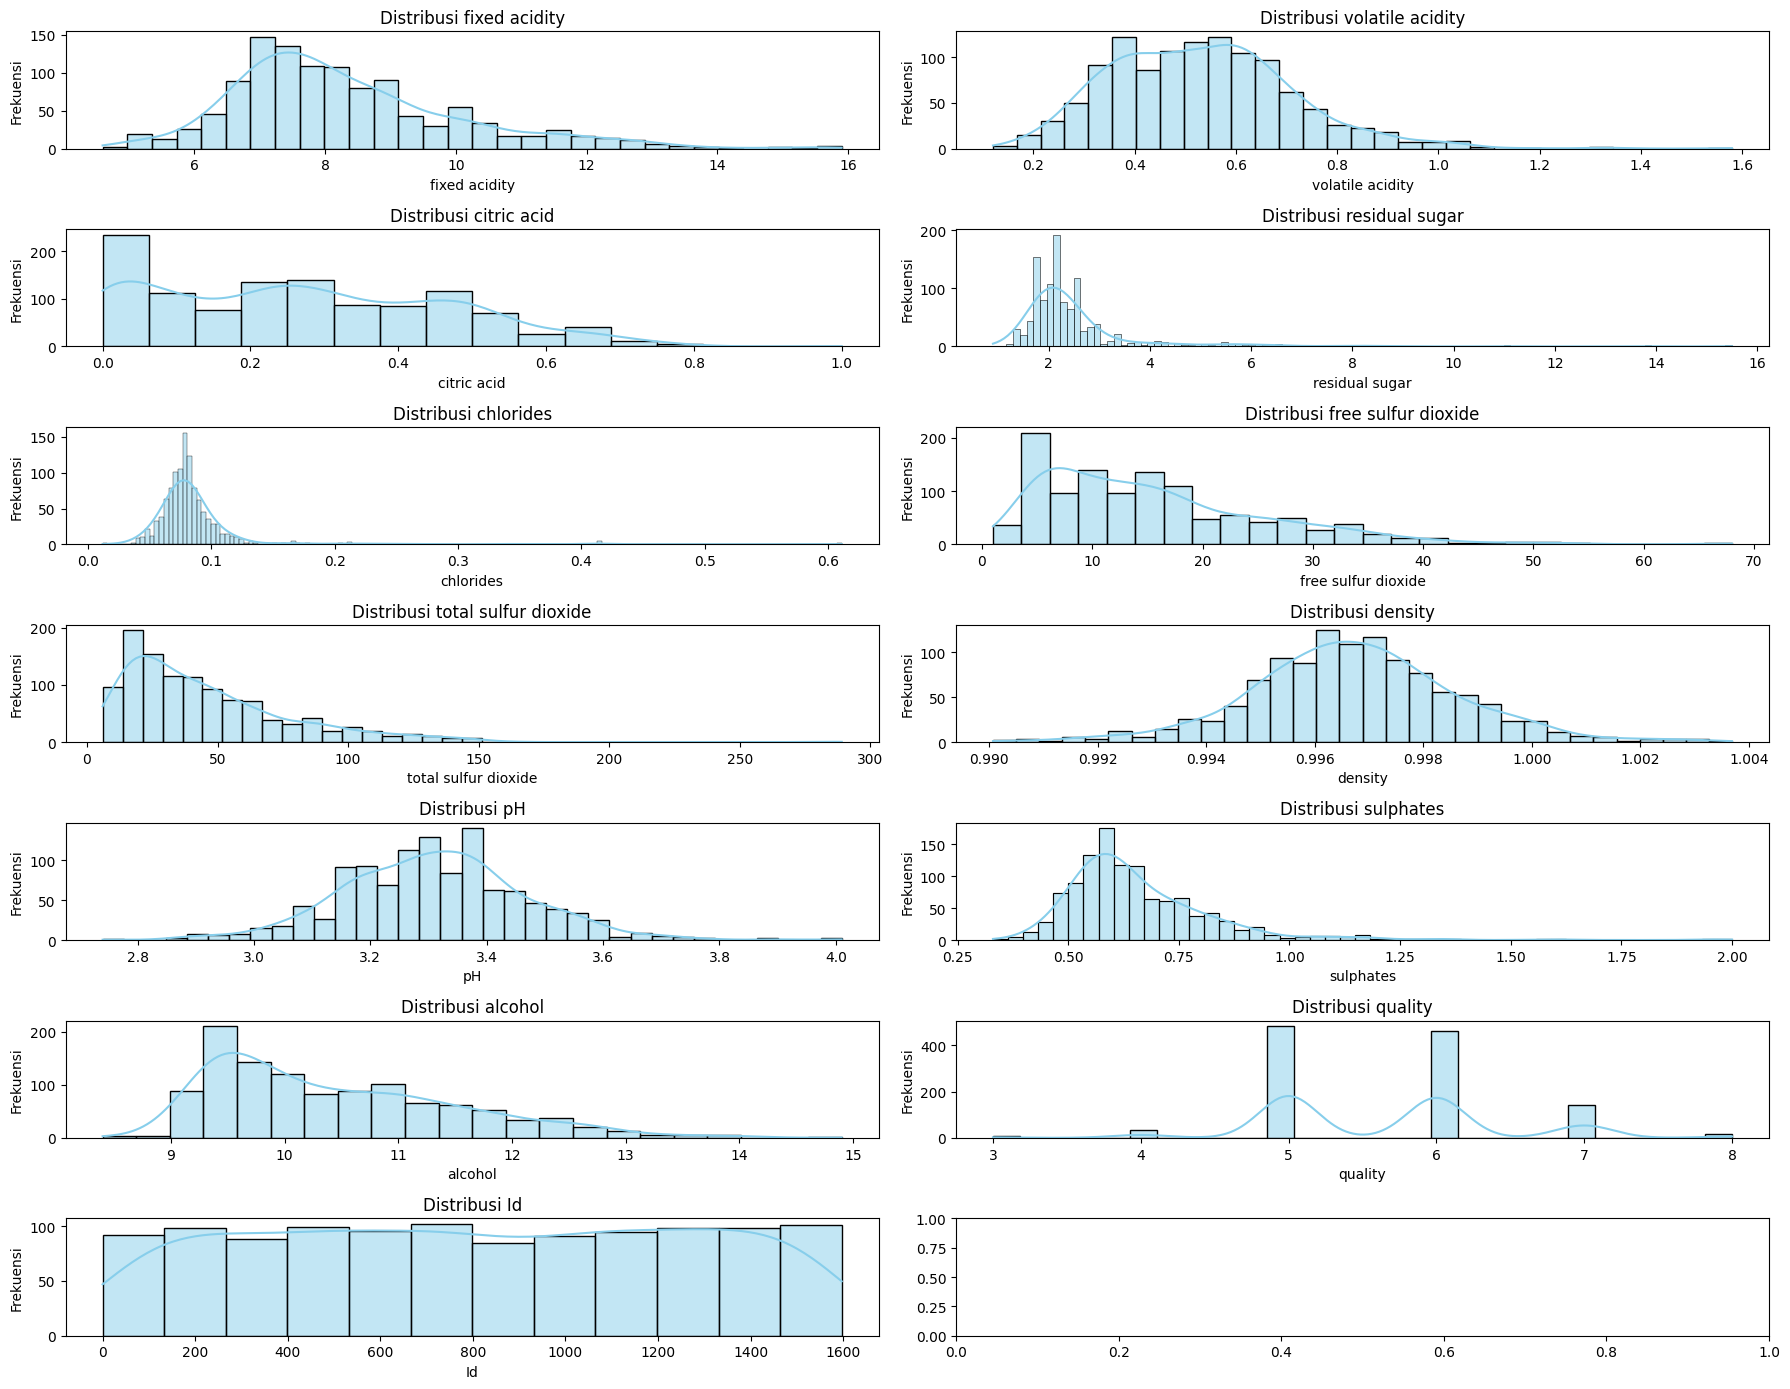

In [20]:
# Bikin grid 7x2
fig, axes = plt.subplots(7, 2, figsize=(18, 14))  # ukuran lebih besar
axes = axes.flatten()  # Supaya mudah di-loop

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### Deteksi Perilaku Outliner

In [21]:
# Fungsi untuk menghitung dan menampilkan data outlier
def lihat_outlier(kolom_data):
    q1 = kolom_data.quantile(0.25)
    q3 = kolom_data.quantile(0.75)
    iqr = q3 - q1

    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr

    outliers = kolom_data[(kolom_data < batas_bawah) | (kolom_data > batas_atas)]
    return outliers  # kembalikan nilai-nilai outlier, bukan jumlahnya

# Tampilkan outlier untuk kolom 'alcohol'
outlier_values = lihat_outlier(df['residual sugar'])
print("Nilai outlier:", outlier_values)

Nilai outlier: 25      5.50
28      5.90
45      4.65
46      4.65
106     5.50
        ... 
1082    4.10
1099    4.40
1106    3.70
1111    6.70
1128    5.10
Name: residual sugar, Length: 110, dtype: float64


In [22]:
# Fungsi untuk menghitung dan menampilkan data outlier
def ringkasan_outlier(df, kolom_list):
    summary = []

    for col in kolom_list:
        data = df[col]
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = data[(data < lower) | (data > upper)]
        jumlah = len(outliers)

        if jumlah == 0:
            keterangan = "Tidak ada outlier"
        else:
            # tandai ekstrem jika outlier jauh dari batas normal
            ekstrem = outliers[(outliers < lower*0.5) | (outliers > upper*1.5)]
            keterangan = "Ekstrem" if len(ekstrem) > 0 else "Wajar"

        summary.append({
            "Kolom": col,
            "Jumlah Outlier": jumlah,
            "Min Outlier": outliers.min() if jumlah > 0 else None,
            "Max Outlier": outliers.max() if jumlah > 0 else None,
            "Keterangan": keterangan
        })

    return pd.DataFrame(summary)

# Misal kolom numerik di dataset
numerik_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality']

tabel_outlier = ringkasan_outlier(df, numerik_cols)
print(tabel_outlier)

                   Kolom  Jumlah Outlier  Min Outlier  Max Outlier Keterangan
0          fixed acidity              44    12.200000     15.90000      Wajar
1       volatile acidity              14     1.020000      1.58000    Ekstrem
2            citric acid               1     1.000000      1.00000      Wajar
3         residual sugar             110     3.700000     15.50000    Ekstrem
4              chlorides              77     0.012000      0.61100    Ekstrem
5    free sulfur dioxide              18    43.000000     68.00000    Ekstrem
6   total sulfur dioxide              40   122.000000    289.00000    Ekstrem
7                density              36     0.990070      1.00369      Wajar
8                     pH              20     2.740000      4.01000      Wajar
9              sulphates              43     1.010000      2.00000    Ekstrem
10               alcohol              12    13.566667     14.90000      Wajar
11               quality              22     3.000000      8.000

In [23]:
# Copy df supaya df asli aman
clean_df = df.copy()

# Daftar kolom ekstrem
ekstrem_cols = ['volatile acidity', 'residual sugar', 'chlorides',
                'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']

for col in ekstrem_cols:
    data = clean_df[col]

    # Hitung IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr

    # Proporsi outlier
    n = len(data)
    prop_upper = sum(data > upper_limit) / n
    prop_lower = sum(data < lower_limit) / n

    # Simpan di kolom baru *_winsor
    clean_df[col + '_winsor'] = winsorize(data, limits=(prop_lower, prop_upper))

# Hapus kolom ekstrem aslinya
clean_df.drop(columns=ekstrem_cols, inplace=True)

In [25]:
clean_df.head()

,fixed acidity,citric acid,density,pH,alcohol,quality,Id,volatile acidity_winsor,residual sugar_winsor,chlorides_winsor,free sulfur dioxide_winsor,total sulfur dioxide_winsor,sulphates_winsor
0,7.4,0.00,0.9978,3.51,9.4,5,0,0.70,1.9,0.076,11.0,34.0,0.56
1,7.8,0.00,0.9968,3.20,9.8,5,1,0.88,2.6,0.098,25.0,67.0,0.68
2,7.8,0.04,0.9970,3.26,9.8,5,2,0.76,2.3,0.092,15.0,54.0,0.65
3,11.2,0.56,0.9980,3.16,9.8,6,3,0.28,1.9,0.075,17.0,60.0,0.58
4,7.4,0.00,0.9978,3.51,9.4,5,4,0.70,1.9,0.076,11.0,34.0,0.56


## Korelasi antar fitur
Gunakan heatmap korelasi untuk melihat hubungan antar variabel

### Sebelum Winsorizing

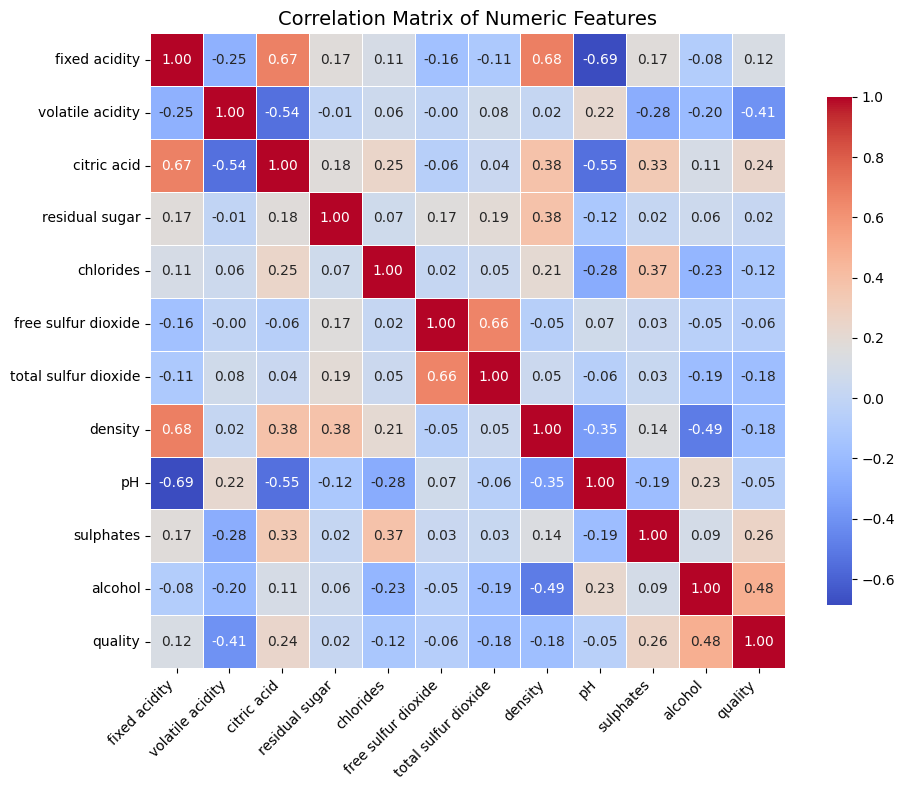

In [28]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Id'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Numeric Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Setelah Winsorizing

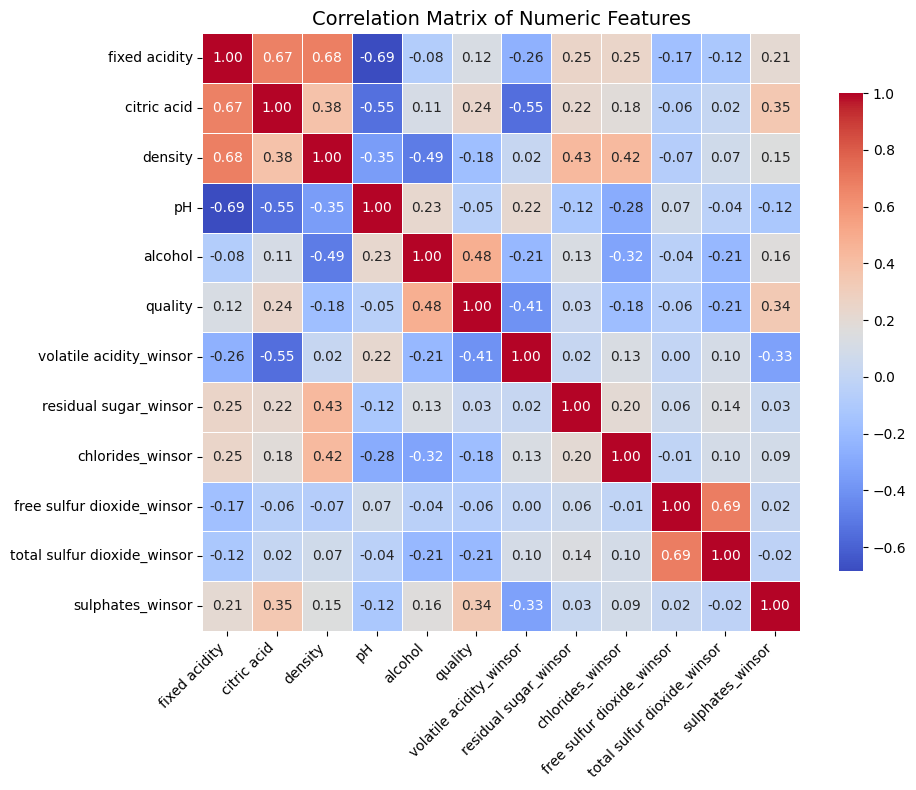

In [29]:
# Select only numeric columns for correlation
numeric_clean_df = clean_df.select_dtypes(include=['int64', 'float64']).drop(columns=['Id'])

# Compute correlation matrix
corr_matrix = numeric_clean_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Numeric Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Perbandingan fitur terhadap target

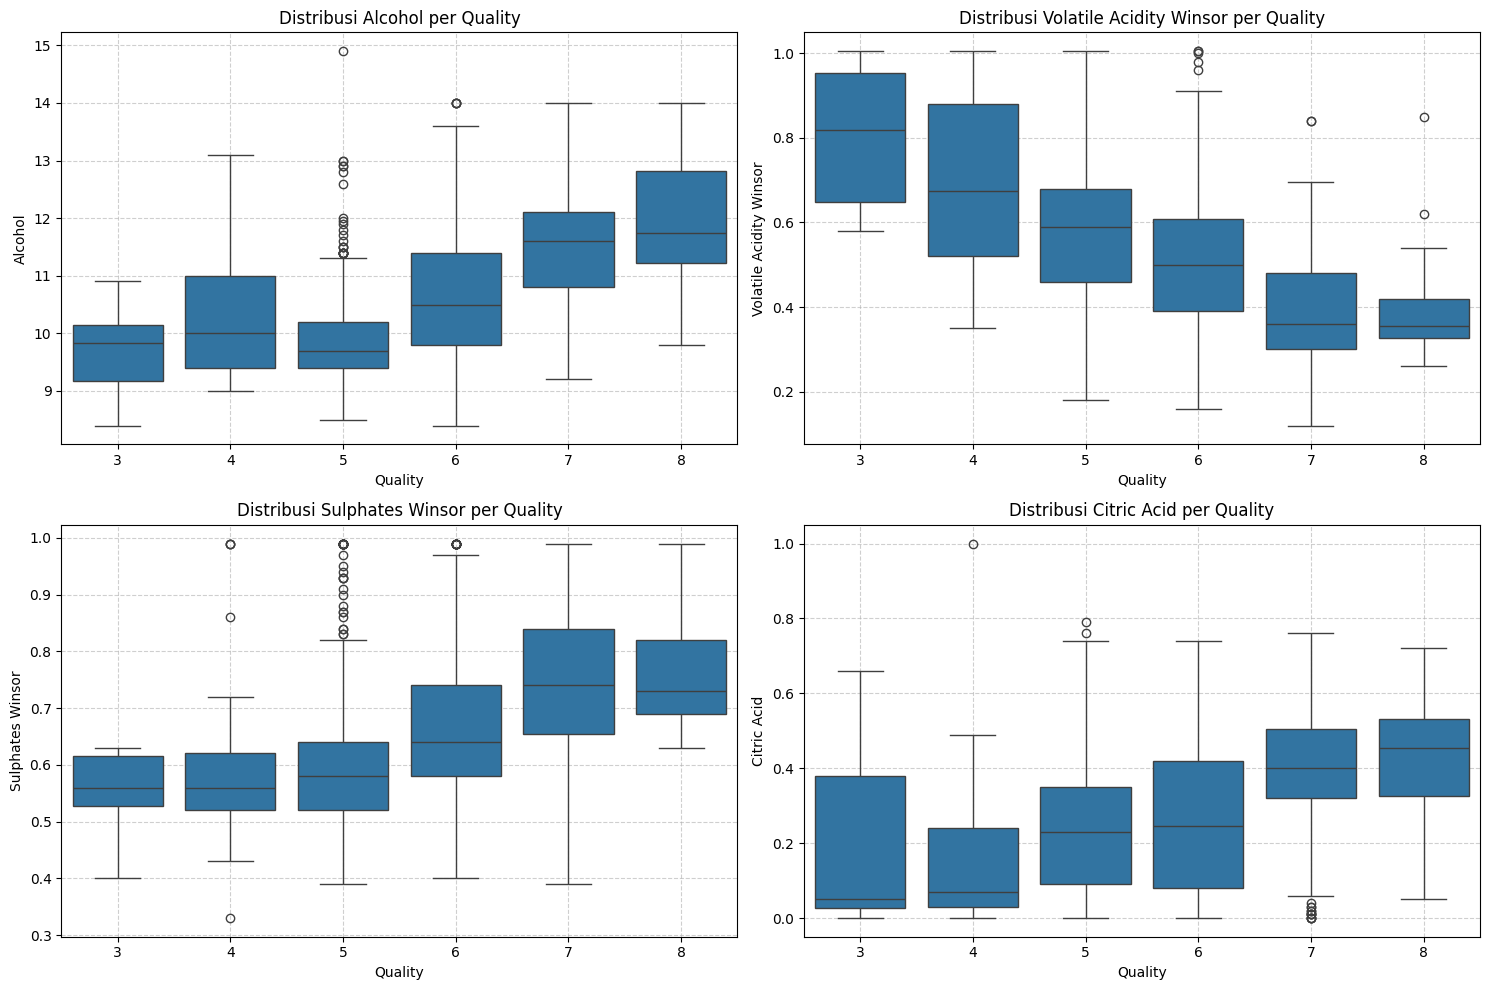

In [30]:
# Daftar fitur numerik yang akan diplot
num_features = ['alcohol', 'volatile acidity_winsor', 'sulphates_winsor', 'citric acid']

# Menyiapkan plot
plt.figure(figsize=(15, 10))

# Membuat subplot untuk setiap fitur
for i, feature in enumerate(num_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='quality', y=feature, data=clean_df)
    plt.title(f'Distribusi {feature.replace("_", " ").title()} per Quality', fontsize=12)
    plt.xlabel('Quality', fontsize=10)
    plt.ylabel(feature.replace("_", " ").title(), fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Simpan Clean Data

In [88]:
label_df = clean_df.copy()

In [89]:
def quality_group(q):
    if q <= 5:
        return 'low'
    else:
        return 'high'

label_df['quality_label'] = label_df['quality'].apply(quality_group)

In [90]:
label_df['quality_label'].value_counts()

,count
quality_label,
high,621
low,522


In [91]:
label_df = label_df.drop(['Id','quality','free sulfur dioxide_winsor'], axis=1)
label_df.head()

,fixed acidity,citric acid,density,pH,alcohol,volatile acidity_winsor,residual sugar_winsor,chlorides_winsor,total sulfur dioxide_winsor,sulphates_winsor,quality_label
0,7.4,0.00,0.9978,3.51,9.4,0.70,1.9,0.076,34.0,0.56,low
1,7.8,0.00,0.9968,3.20,9.8,0.88,2.6,0.098,67.0,0.68,low
2,7.8,0.04,0.9970,3.26,9.8,0.76,2.3,0.092,54.0,0.65,low
3,11.2,0.56,0.9980,3.16,9.8,0.28,1.9,0.075,60.0,0.58,high
4,7.4,0.00,0.9978,3.51,9.4,0.70,1.9,0.076,34.0,0.56,low


## Pembagian data train

In [92]:
numeric_df = label_df.select_dtypes(include=['int64', 'float64']).columns
category_df = label_df.select_dtypes(include=['object']).columns

print(numeric_df.to_list())
print(category_df.to_list())

['fixed acidity', 'citric acid', 'density', 'pH', 'alcohol', 'volatile acidity_winsor', 'residual sugar_winsor', 'chlorides_winsor', 'total sulfur dioxide_winsor', 'sulphates_winsor']
['quality_label']


## Encoding

In [93]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
label_df['quality_label'] = le.fit_transform(label_df['quality_label'])
label_df.head()

,fixed acidity,citric acid,density,pH,alcohol,volatile acidity_winsor,residual sugar_winsor,chlorides_winsor,total sulfur dioxide_winsor,sulphates_winsor,quality_label
0,7.4,0.00,0.9978,3.51,9.4,0.70,1.9,0.076,34.0,0.56,1
1,7.8,0.00,0.9968,3.20,9.8,0.88,2.6,0.098,67.0,0.68,1
2,7.8,0.04,0.9970,3.26,9.8,0.76,2.3,0.092,54.0,0.65,1
3,11.2,0.56,0.9980,3.16,9.8,0.28,1.9,0.075,60.0,0.58,0
4,7.4,0.00,0.9978,3.51,9.4,0.70,1.9,0.076,34.0,0.56,1


In [94]:
# Misal clean_df masih punya kolom 'quality'
X = label_df.drop('quality_label', axis=1)  # semua kolom kecuali 'quality'
y = label_df['quality_label']               # kolom target

In [95]:
print(y.value_counts())

quality_label
0    621
1    522
Name: count, dtype: int64


In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [97]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
print(y.value_counts())
print(y_res.value_counts())

quality_label
0    621
1    522
Name: count, dtype: int64
quality_label
1    497
0    497
Name: count, dtype: int64


## Scalling data

In [101]:
scaler = RobustScaler()

# Fit scaler hanya di training set
X_train_res_scaled = scaler.fit_transform(X_res)

# Transform test set dengan scaler yang sama
X_test_scaled = scaler.transform(X_test)

## Modelling

In [104]:
from sklearn.linear_model import LogisticRegression
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42,class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
}

In [105]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(f"Score: {score:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

for name, model in models.items():
    print(f"===== {name} =====")
    if name in ["SVM", "KNN", "Logistic Regression"]:
        evaluate_model(model, X_train_res_scaled, y_res, X_test_scaled, y_test)
    else:
        evaluate_model(model, X_res, y_res, X_test, y_test)
    print("\n")

===== Logistic Regression =====
Score: 0.7598
              precision    recall  f1-score   support

           0       0.79      0.76      0.77       124
           1       0.73      0.76      0.74       105

    accuracy                           0.76       229
   macro avg       0.76      0.76      0.76       229
weighted avg       0.76      0.76      0.76       229

[[94 30]
 [25 80]]


===== Random Forest =====
Score: 0.7991
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       124
           1       0.77      0.80      0.79       105

    accuracy                           0.80       229
   macro avg       0.80      0.80      0.80       229
weighted avg       0.80      0.80      0.80       229

[[99 25]
 [21 84]]


===== XGBoost =====
Score: 0.7598
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       124
           1       0.75      0.71      0.73       105

    accuracy        

## Hypertuning

In [107]:
# Model awal
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Range parameter yang mau diuji
param_dist = {
    'n_estimators': randint(100, 500),         # jumlah pohon
    'max_depth': [None, 5, 10, 20, 30],       # kedalaman pohon
    'min_samples_split': randint(2, 10),      # min sampel utk split
    'min_samples_leaf': randint(1, 5),        # min sampel di daun
    'max_features': ['sqrt', 'log2', None]    # fitur maksimum tiap split
}

# Randomized Search
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,                  # jumlah kombinasi coba
    cv=5,                       # 5-fold cross validation
    scoring='accuracy',         # metrik evaluasi
    random_state=42,
    n_jobs=-1,                  # pakai semua core CPU
    verbose=2
)

# Fit ke data training yang sudah SMOTE + scaling
random_search.fit(X_train_res_scaled, y_res)

# Hasil terbaik
print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# Model terbaik
best_rf = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 291}
Best CV score: 0.7948175219532003


In [108]:
y_pred = best_rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80       124
           1       0.77      0.78      0.77       105

    accuracy                           0.79       229
   macro avg       0.79      0.79      0.79       229
weighted avg       0.79      0.79      0.79       229

[[99 25]
 [23 82]]


In [124]:
# Misal rf_model sudah dilatih
joblib.dump(models['Random Forest'], "rf_model.pkl")
print("Model berhasil disimpan ke rf_model.pkl")

Model berhasil disimpan ke rf_model.pkl


## Hasil inference/labeling satu data

In [121]:
# Misal model sudah dilatih
rf_model = models['Random Forest']
rf_model.fit(X_res, y_res)

# Misal X_test punya kolom yang sama seperti X_res
single_sample = X_test.iloc[0]  # ambil baris pertama
single_sample_df = pd.DataFrame([single_sample], columns=X_res.columns)

# Prediksi
pred_class = rf_model.predict(single_sample_df)[0]
pred_prob = rf_model.predict_proba(single_sample_df)[0]

print(f"Predicted class: {pred_class}")
print(f"Predicted probability: {pred_prob}")

Predicted class: 1
Predicted probability: [0.15 0.85]
